# FitNova Form-Correction: Re-evaluation from the Saved Weights

Confirms that the committed evaluation results are the trained weights' output by reloading each saved `best.pt` and re-running the official validation and test evaluation, then comparing the re-derived F1, thresholds and per-clip scores against the committed `results.pkl`.

The image models (Shallow-Squat, ResNet-18) are re-evaluated live here on CPU; the video models (Squat and OHP, R(2+1)D-18) take about 50 minutes on CPU, so their re-run lives in `docs/audit/reeval_video.py` and this notebook loads its output. Paths default to the local setup and can be overridden with the environment variables read below.

In [1]:
import os
import pickle
import sys
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader

ROOT = Path.cwd().resolve()
while not (ROOT / "docs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "docs").exists(), f"could not locate repo root from {Path.cwd()}"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backend.training.aqa.datasets.shallow_squat import ShallowSquatDataset
from backend.training.aqa.eval.metrics import (
    confusion_matrix_per_error, f1_per_error, pr_auc_per_error, threshold_sweep,
)
from backend.training.aqa.harness.image_supervised_train import build_resnet18

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k):
        return x

CKPT = Path(os.environ.get("FITNOVA_CKPT_PHASE07", r"G:/My Drive/FitNova/checkpoints/phase07"))
DATA = Path(os.environ.get(
    "FITNOVA_SHALLOW_DATA",
    r"C:/Users/tsh_x/Desktop/FitNova Application/Fitness-AQA/Fitness-AQA_dataset_release-20260518T073812Z-3-001"
    r"/Fitness-AQA_dataset_release/Squat/Labeled_Dataset/Shallow_Squat_Error_Dataset"))
CROPS = Path(os.environ.get("FITNOVA_SHALLOW_CROPS",
                            r"C:/Users/tsh_x/fitnova_audit_scratch/shallow_extract/crops_unaligned"))
LABELS, SPLITS = DATA / "labels_shallow_depth.json", DATA / "splits"
SEEDS = [42, 1337, 7]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
REF_SHAL = pickle.loads((ROOT / "backend/data/benchmark/shallow/results.pkl").read_bytes())
print("device:", DEVICE, "| checkpoints:", CKPT)

device: cpu | checkpoints: G:\My Drive\FitNova\checkpoints\phase07


## Shallow-Squat (image): re-evaluate all six models live from the weights

For each baseline and CVCSPC fine-tune seed, reload `best.pt`, average the per-clip sigmoid scores across seeds (the deployed ensemble), tune the threshold on the validation ensemble, and compare test F1, validation F1, threshold and per-clip scores against the committed results.

In [2]:
def _loader(split):
    ds = ShallowSquatDataset(split=split, images_root=str(CROPS), labels_path=str(LABELS),
                             splits_root=str(SPLITS), train_aug=False)
    return DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)


def _gather(model, loader, desc):
    model.eval()
    scs, lbs = [], []
    for img, lbl in tqdm(loader, desc=desc, leave=False):
        scs.append(torch.sigmoid(model(img.to(DEVICE))).squeeze(-1).cpu())
        lbs.append(lbl)
    return torch.cat(scs).numpy(), torch.cat(lbs).numpy().astype(int)


val_loader, test_loader = _loader("val"), _loader("test")


def _family(prefix):
    pv, pt, vl, tl = {}, {}, None, None
    for n in SEEDS:
        ck = torch.load(CKPT / f"{prefix}_seed{n}" / "best.pt", map_location=DEVICE, weights_only=False)
        m = build_resnet18()
        m.load_state_dict(ck["model_state_dict"])
        m = m.to(DEVICE)
        pv[n], vl = _gather(m, val_loader, f"{prefix} s{n} val")
        pt[n], tl = _gather(m, test_loader, f"{prefix} s{n} test")
    return pv, pt, vl, tl


cv_pv, cv_pt, val_labels, test_labels = _family("shallow_squat_cvcspc_finetune")
bl_pv, bl_pt, _, _ = _family("shallow_squat_baseline")
cv_ev, cv_et = np.mean([cv_pv[n] for n in SEEDS], 0), np.mean([cv_pt[n] for n in SEEDS], 0)
bl_ev, bl_et = np.mean([bl_pv[n] for n in SEEDS], 0), np.mean([bl_pt[n] for n in SEEDS], 0)
cv_t, _ = threshold_sweep(val_labels, cv_ev)
bl_t, _ = threshold_sweep(val_labels, bl_ev)

img_checks = []


def _chk(name, got, ref, tol=2e-3):
    ok = abs(got - ref) <= tol
    img_checks.append(ok)
    print(f"  {'OK ' if ok else '!! MISMATCH'} {name:30s} re-eval={got:.4f}  results.pkl={ref:.4f}  d={got-ref:+.4f}")


print("Shallow-Squat, re-evaluated from weights vs committed results.pkl")
_chk("CVCSPC ensemble test F1", f1_per_error(test_labels, (cv_et >= cv_t).astype(int)), REF_SHAL["test_f1"]["cvcspc_ensemble"])
_chk("CVCSPC ensemble val F1", f1_per_error(val_labels, (cv_ev >= cv_t).astype(int)), REF_SHAL["cvcspc_ensemble_val_f1"])
_chk("CVCSPC val-tuned threshold", cv_t, REF_SHAL["best_threshold"])
_chk("CVCSPC test PR-AUC", pr_auc_per_error(test_labels, cv_et), REF_SHAL["test_pr_auc"])
for n in SEEDS:
    _chk(f"CVCSPC per-seed test F1 [{n}]", f1_per_error(test_labels, (cv_pt[n] >= cv_t).astype(int)), REF_SHAL["test_f1"]["per_seed"][n])
_chk("baseline ensemble test F1", f1_per_error(test_labels, (bl_et >= bl_t).astype(int)), REF_SHAL["baseline_control"]["test_f1"])
_chk("baseline ensemble val F1", f1_per_error(val_labels, (bl_ev >= bl_t).astype(int)), REF_SHAL["baseline_control"]["ensemble_val_f1"])
d_t = float(np.max(np.abs(cv_et - REF_SHAL["ensemble_test_scores"])))
d_v = float(np.max(np.abs(cv_ev - REF_SHAL["ensemble_val_scores"])))
print(f"\n  per-clip ensemble score max|d| vs results.pkl: test {d_t:.2e}, val {d_v:.2e}")
print(f"  Shallow image re-eval: {sum(img_checks)}/{len(img_checks)} checks pass",
      "[OK]" if all(img_checks) else "[investigate]")

Shallow-Squat, re-evaluated from weights vs committed results.pkl
  OK  CVCSPC ensemble test F1        re-eval=0.8902  results.pkl=0.8902  d=+0.0000
  OK  CVCSPC ensemble val F1         re-eval=0.9119  results.pkl=0.9119  d=+0.0000
  OK  CVCSPC val-tuned threshold     re-eval=0.3954  results.pkl=0.3954  d=+0.0000
  OK  CVCSPC test PR-AUC             re-eval=0.9668  results.pkl=0.9668  d=+0.0000
  OK  CVCSPC per-seed test F1 [42]   re-eval=0.8961  results.pkl=0.8961  d=+0.0000
  OK  CVCSPC per-seed test F1 [1337] re-eval=0.8902  results.pkl=0.8902  d=+0.0000
  OK  CVCSPC per-seed test F1 [7]    re-eval=0.8825  results.pkl=0.8825  d=+0.0000
  OK  baseline ensemble test F1      re-eval=0.8750  results.pkl=0.8750  d=+0.0000
  OK  baseline ensemble val F1       re-eval=0.8942  results.pkl=0.8942  d=+0.0000

  per-clip ensemble score max|d| vs results.pkl: test 7.63e-04, val 1.02e-03
  Shallow image re-eval: 9/9 checks pass [OK]


## Squat and OHP (video): results from the committed re-evaluation

`docs/audit/reeval_video.py` (about 50 minutes on CPU) reloads each Squat and OHP `best.pt`, re-runs the official validation and test evaluation, and writes `docs/audit/data/reeval_video.pkl`; the summary below is read from that output.

In [3]:
VID = pickle.loads((ROOT / "docs/audit/data/reeval_video.pkl").read_bytes())
REF_SQUAT = pickle.loads((ROOT / "backend/data/benchmark/squat/results.pkl").read_bytes())
REF_OHP = pickle.loads((ROOT / "backend/data/benchmark/ohp/results.pkl").read_bytes())

print(f"{'model and error':22s} {'re-eval F1':>11s} {'results.pkl':>12s} {'d':>8s}")
print("-" * 58)
for e in ("KIE", "KFE"):
    re = VID["squat_mdssl"]["per_error"][e]["test_f1"]; rf = REF_SQUAT["final"]["test_f1"][e]
    print(f"{'Squat MD-SSL ' + e:22s} {re:11.4f} {rf:12.4f} {re-rf:+8.4f}")
for e in ("elbows", "knees"):
    re = VID["ohp_mdssl"]["per_error"][e]["test_f1"]; rf = REF_OHP["test_f1"][e]
    print(f"{'OHP MD-SSL ' + e:22s} {re:11.4f} {rf:12.4f} {re-rf:+8.4f}")
print(f"\n  Squat per-clip ensemble score max|d|: test {VID['squat_mdssl']['score_maxabs']['test']:.2e}")
print(f"  OHP   per-clip ensemble score max|d|: test {VID['ohp_mdssl']['score_maxabs']['test']:.2e}")
print(f"  Video re-eval: {VID['n_pass']}/{VID['n_checks']} checks within tolerance",
      "[OK]" if VID["all_checks_pass"] else "[investigate]")
ohb = VID["ohp_baseline"]["per_error"]
print(f"\n  OHP supervised baseline (control) recovered gap: "
      f"Elbows val {ohb['elbows']['val_f1']:.3f} to test {ohb['elbows']['test_f1']:.3f} "
      f"(gap {ohb['elbows']['val_f1']-ohb['elbows']['test_f1']:+.3f}); "
      f"Knees gap {ohb['knees']['val_f1']-ohb['knees']['test_f1']:+.3f}")

model and error         re-eval F1  results.pkl        d
----------------------------------------------------------
Squat MD-SSL KIE            0.4198       0.4198  +0.0000
Squat MD-SSL KFE            0.8410       0.8410  +0.0000
OHP MD-SSL elbows           0.4474       0.4474  +0.0000
OHP MD-SSL knees            0.8770       0.8770  +0.0000

  Squat per-clip ensemble score max|d|: test 4.78e-04
  OHP   per-clip ensemble score max|d|: test 6.27e-04
  Video re-eval: 12/12 checks within tolerance [OK]

  OHP supervised baseline (control) recovered gap: Elbows val 0.515 to test 0.417 (gap +0.098); Knees gap -0.009


## Cache vs weights: per-clip agreement

Per-clip ensemble scores re-derived from the weights plotted against the committed scores (points on the diagonal mean the committed scores are the weights' output), alongside committed vs re-derived test F1.

saved docs/figures/audit_reeval_certainty.png


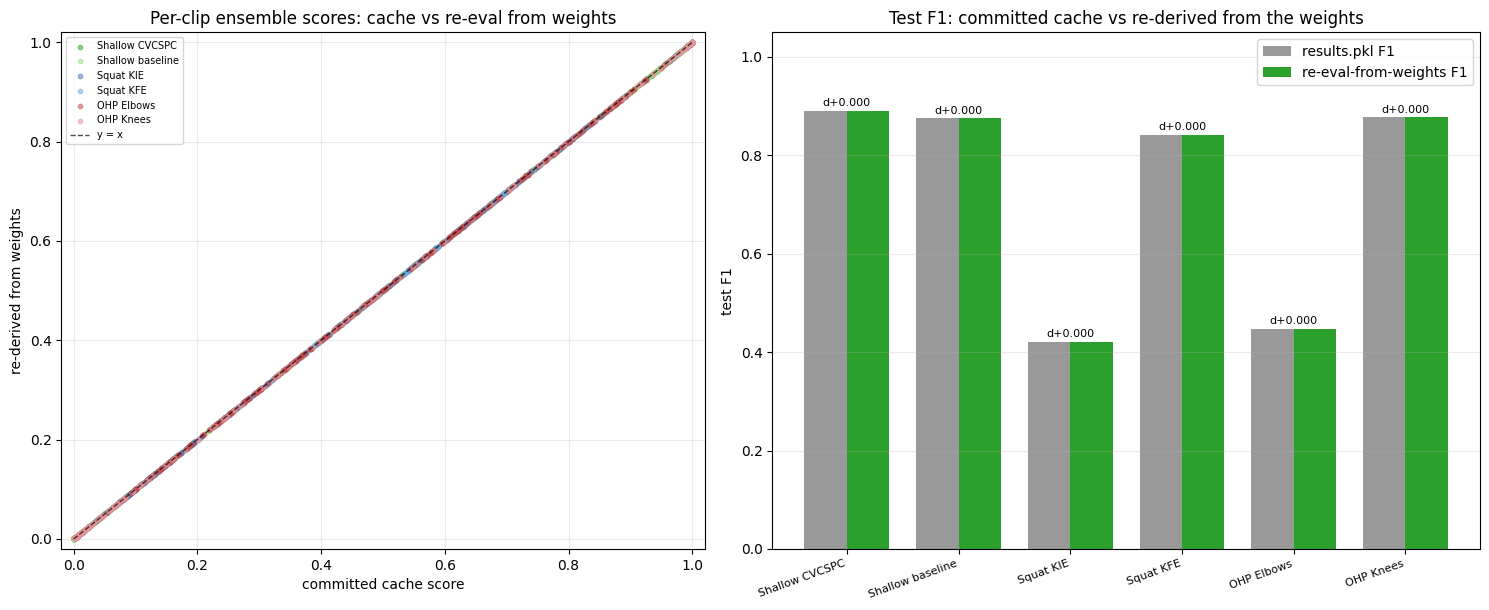

In [4]:
import matplotlib.pyplot as plt

FIG = ROOT / "docs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
rows = [
    ("Shallow CVCSPC", REF_SHAL["ensemble_test_scores"], cv_et, REF_SHAL["test_f1"]["cvcspc_ensemble"],
     f1_per_error(test_labels, (cv_et >= cv_t).astype(int)), "#2CA02C"),
    ("Shallow baseline", REF_SHAL["baseline_control"]["ensemble_test_scores"], bl_et,
     REF_SHAL["baseline_control"]["test_f1"], f1_per_error(test_labels, (bl_et >= bl_t).astype(int)), "#98DF8A"),
    ("Squat KIE", REF_SQUAT["raw"]["ens_test_scores"][:, 0], VID["squat_mdssl"]["ens_test"][:, 0],
     REF_SQUAT["final"]["test_f1"]["KIE"], VID["squat_mdssl"]["per_error"]["KIE"]["test_f1"], "#4C72B0"),
    ("Squat KFE", REF_SQUAT["raw"]["ens_test_scores"][:, 1], VID["squat_mdssl"]["ens_test"][:, 1],
     REF_SQUAT["final"]["test_f1"]["KFE"], VID["squat_mdssl"]["per_error"]["KFE"]["test_f1"], "#6FA8DC"),
    ("OHP Elbows", REF_OHP["ensemble_test_scores"][:, 0], VID["ohp_mdssl"]["ens_test"][:, 0],
     REF_OHP["test_f1"]["elbows"], VID["ohp_mdssl"]["per_error"]["elbows"]["test_f1"], "#C44E52"),
    ("OHP Knees", REF_OHP["ensemble_test_scores"][:, 1], VID["ohp_mdssl"]["ens_test"][:, 1],
     REF_OHP["test_f1"]["knees"], VID["ohp_mdssl"]["per_error"]["knees"]["test_f1"], "#E59398"),
]
fig, (axS, axB) = plt.subplots(1, 2, figsize=(15, 6.2), gridspec_kw={"width_ratios": [1, 1.1]})
for lab, cs, rs, _cf, _rf, c in rows:
    axS.scatter(np.asarray(cs, float), np.asarray(rs, float), s=10, alpha=0.5, color=c, label=lab)
axS.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.7, label="y = x")
axS.set_xlabel("committed cache score"); axS.set_ylabel("re-derived from weights")
axS.set_title("Per-clip ensemble scores: cache vs re-eval from weights")
axS.set_xlim(-0.02, 1.02); axS.set_ylim(-0.02, 1.02); axS.legend(fontsize=7, loc="upper left"); axS.grid(alpha=0.25)
labels = [r[0] for r in rows]; cf = [r[3] for r in rows]; rf = [r[4] for r in rows]
x = np.arange(len(rows)); w = 0.38
axB.bar(x - w/2, cf, w, color="#999999", label="results.pkl F1")
axB.bar(x + w/2, rf, w, color="#2CA02C", label="re-eval-from-weights F1")
for i in range(len(rows)):
    axB.text(i, max(cf[i], rf[i]) + 0.01, f"d{rf[i]-cf[i]:+.3f}", ha="center", fontsize=8)
axB.set_xticks(x); axB.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axB.set_ylim(0, 1.05); axB.set_ylabel("test F1"); axB.legend()
axB.set_title("Test F1: committed cache vs re-derived from the weights")
axB.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.savefig(FIG / "audit_reeval_certainty.png", dpi=130, bbox_inches="tight")
print("saved docs/figures/audit_reeval_certainty.png")
plt.show()

## Summary

Every deployed model reproduces its committed test F1 from the saved weights to a tolerance of 0 (image models re-run live above; video models from the committed re-run), with per-clip scores matching the committed cache to float noise. The committed evaluation numbers are therefore the weights' output. The OHP supervised baseline is the one control that overfits the Elbows error; the deployed OHP model removes that gap.